# 📊 Análisis del Dataset Zenodo - SafeTalk

**Objetivo:** Analizar el dataset OffendES de Zenodo para detección de bullying/hate speech

**Dataset:** Zenodo OffendES
- Fuente: https://zenodo.org/records/2592149
- Tamaño: ~6,000 ejemplos
- Idioma: Español (España)
- Clases: 
  - 0 = No ofensivo
  - 1 = Ofensivo/Hate speech

---

In [1]:

# Librerías básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

# Configuración
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("✅ Librerías importadas correctamente")
print(f"📊 Pandas version: {pd.__version__}")
print(f"📈 Matplotlib version: {plt.matplotlib.__version__}")
print(f"🎨 Seaborn version: {sns.__version__}")

✅ Librerías importadas correctamente
📊 Pandas version: 3.0.2
📈 Matplotlib version: 3.10.8
🎨 Seaborn version: 0.13.2


## 1. Cargar Dataset

In [2]:

dataset_path = Path('../data/raw/zenodo_procesado.csv')

# Verificar que existe
if not dataset_path.exists():
    print(f"❌ ERROR: No se encontró el archivo en {dataset_path}")
    
else:
    print(f" Archivo encontrado: {dataset_path}")

# Cargar
df = pd.read_csv(dataset_path)

print(f"\n{'='*70}")
print(f"DATASET CARGADO EXITOSAMENTE")
print(f"{'='*70}")

print(f"\n Total de ejemplos: {len(df):,}")
print(f" Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")

# Mostrar primeras 10 filas
print(f"\n Primeras 10 filas del dataset:")
df.head(10)

 Archivo encontrado: ..\data\raw\zenodo_procesado.csv

DATASET CARGADO EXITOSAMENTE

 Total de ejemplos: 6,000
 Dimensiones: 6,000 filas × 3 columnas

 Primeras 10 filas del dataset:


,texto,label,fuente
0,Ismael es egocentrico porque se vuelve loca si...,0,zenodo
1,..ya tardaba en salir quien pronunciase nombre...,0,zenodo
2,"(Esto no es un discurso político y razonado, o...",0,zenodo
3,"Muy despreciados,siiii,pero todos vestidos de ...",1,zenodo
4,marica explicame porque a veces no te entiendo...,1,zenodo
5,Abusan de 1400 niñas durante 16 años porque la...,0,zenodo
6,"Es ridículo, ayer le dije a un árabe que no er...",0,zenodo
7,39. Me considero género no binario y mis prono...,0,zenodo
8,@SuperFalete jajajajaja. Te jodes maricon.,1,zenodo
9,Pero por qué cojones sois tan racistas contra ...,0,zenodo


## 2. Información General del Dataset

In [3]:

print(f"{'='*70}")
print(f"📋 INFORMACIÓN GENERAL DEL DATASET")
print(f"{'='*70}")

# Columnas
print(f"\n📊 Columnas disponibles:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i}. {col} ({df[col].dtype})")

# Tipos de datos
print(f"\n Tipos de datos:")
print(df.dtypes)

# Información resumida
print(f"\nInformación del DataFrame:")
df.info()

# Valores nulos
print(f"\n Valores nulos por columna:")
nulos = df.isnull().sum()
if nulos.sum() == 0:
    print("    No hay valores nulos en ninguna columna")
else:
    print(nulos[nulos > 0])

# Estadísticas básicas
print(f"\n Estadísticas básicas:")
print(df.describe(include='all'))

📋 INFORMACIÓN GENERAL DEL DATASET

📊 Columnas disponibles:
   1. texto (str)
   2. label (int64)
   3. fuente (str)

 Tipos de datos:
texto       str
label     int64
fuente      str
dtype: object

Información del DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   texto   6000 non-null   str  
 1   label   6000 non-null   int64
 2   fuente  6000 non-null   str  
dtypes: int64(1), str(2)
memory usage: 852.1 KB

 Valores nulos por columna:
    No hay valores nulos en ninguna columna

 Estadísticas básicas:
                                                   texto        label  fuente
count                                               6000  6000.000000    6000
unique                                              5999          NaN       1
top     EL MAMÓN DE ALECO YA ME HA HECHO FREGAR DE NUEVO          NaN  zenodo
freq                                             

## 3. Análisis de Clases (Balance del Dataset)

El **balanceo de clases** es crítico. Si una clase tiene muchos más ejemplos que la otra, el modelo puede aprender sesgado.

**Ideal:** 50% clase 0, 50% clase 1  
**Aceptable:** 40%-60% (ratio hasta 1.5:1)  
**Problemático:** >60% de una clase (ratio >2:1)

 DISTRIBUCIÓN DE CLASES

 Cantidad por clase:
   Clase 0 (No ofensivo         ): 4,433 ejemplos ( 73.9%)
   Clase 1 (Ofensivo/Hate speech): 1,567 ejemplos ( 26.1%)

 Análisis de balanceo:
   Ratio: 2.83:1
   Diferencia absoluta: 2,866 ejemplos
   ❌ Malo: Muy desbalanceado (se recomienda balancear)


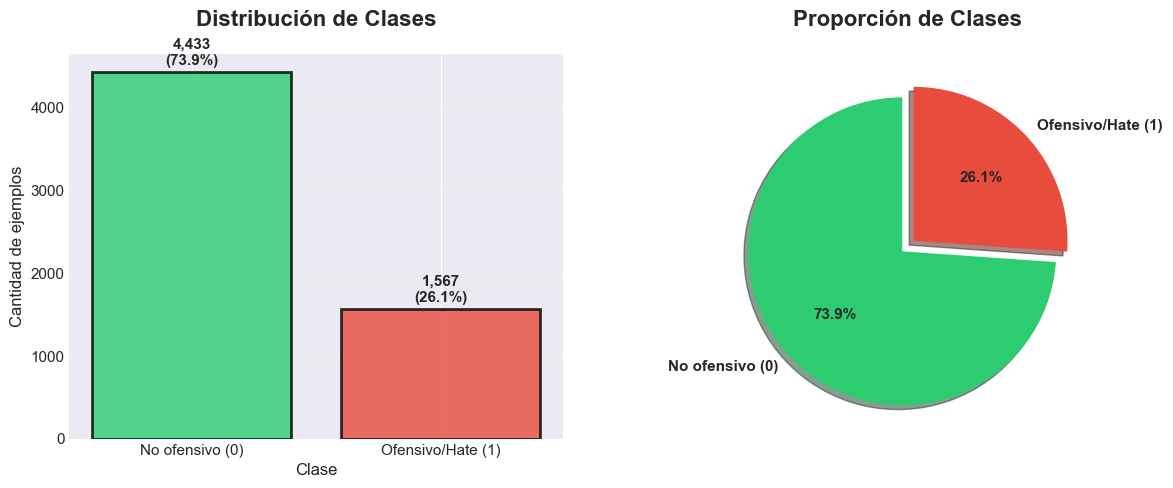

In [8]:

print(f"{'='*70}")
print(f" DISTRIBUCIÓN DE CLASES")
print(f"{'='*70}")

# Contar ejemplos por clase
distribucion = df['label'].value_counts().sort_index()

print(f"\n Cantidad por clase:")
for label, count in distribucion.items():
    porcentaje = (count / len(df)) * 100
    nombre_clase = "No ofensivo" if label == 0 else "Ofensivo/Hate speech"
    print(f"   Clase {label} ({nombre_clase:20s}): {count:5,} ejemplos ({porcentaje:5.1f}%)")

# Calcular ratio de balanceo
ratio = max(distribucion) / min(distribucion)
diferencia = abs(distribucion[0] - distribucion[1])

print(f"\n Análisis de balanceo:")
print(f"   Ratio: {ratio:.2f}:1")
print(f"   Diferencia absoluta: {diferencia:,} ejemplos")

if ratio < 1.3:
    print(f"    Excelente: Dataset muy bien balanceado")
    color_status = "green"
elif ratio < 1.5:
    print(f"    Bueno: Dataset aceptablemente balanceado")
    color_status = "green"
elif ratio < 2.0:
    print(f"    Regular: Ligeramente desbalanceado (considerar técnicas de balanceo)")
    color_status = "orange"
else:
    print(f"   ❌ Malo: Muy desbalanceado (se recomienda balancear)")
    color_status = "red"

# VISUALIZACIÓN
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
colors = ['#2ecc71', '#e74c3c']  # Verde para 0, Rojo para 1
bars = axes[0].bar(
    ['No ofensivo (0)', 'Ofensivo/Hate (1)'],
    distribucion.values,
    color=colors,
    edgecolor='black',
    linewidth=2,
    alpha=0.8
)

axes[0].set_title('Distribución de Clases', fontsize=16, fontweight='bold', pad=20)
axes[0].set_ylabel('Cantidad de ejemplos', fontsize=12)
axes[0].set_xlabel('Clase', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

# Añadir valores en las barras
for i, (bar, value) in enumerate(zip(bars, distribucion.values)):
    height = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width()/2., 
        height + 50,
        f'{value:,}\n({value/len(df)*100:.1f}%)',
        ha='center', 
        va='bottom', 
        fontweight='bold',
        fontsize=11
    )

# Gráfico de pastel
explode = (0.05, 0.05)  # Separar un poco las porciones
axes[1].pie(
    distribucion.values,
    labels=['No ofensivo (0)', 'Ofensivo/Hate (1)'],
    autopct='%1.1f%%',
    colors=colors,
    explode=explode,
    shadow=True,
    startangle=90,
    textprops={'fontsize': 11, 'fontweight': 'bold'}
)
axes[1].set_title('Proporción de Clases', fontsize=16, fontweight='bold', pad=20)

plt.show()



## 4. Análisis de Longitud de Textos

La **longitud de los textos** nos dice:
- ¿Son tweets cortos o textos largos?
- ¿Hay diferencia entre clases?
- ¿Necesitamos recortar textos muy largos?

📏 ANÁLISIS DE LONGITUD DE TEXTOS

 Estadísticas de longitud (caracteres):
count    6000.000000
mean      113.258833
std        44.712881
min        23.000000
25%        81.000000
50%       116.000000
75%       138.000000
max       342.000000
Name: longitud_chars, dtype: float64

 Estadísticas de longitud (palabras):
count    6000.000000
mean       17.950833
std         7.793301
min         3.000000
25%        12.000000
50%        18.000000
75%        22.000000
max        56.000000
Name: longitud_palabras, dtype: float64

 Longitud promedio por clase:

   Clase 0 (No ofensivo):
      Media: 116.0 caracteres, 18.3 palabras
      Mediana: 119 caracteres

   Clase 1 (Ofensivo/Hate):
      Media: 105.4 caracteres, 16.9 palabras
      Mediana: 105 caracteres


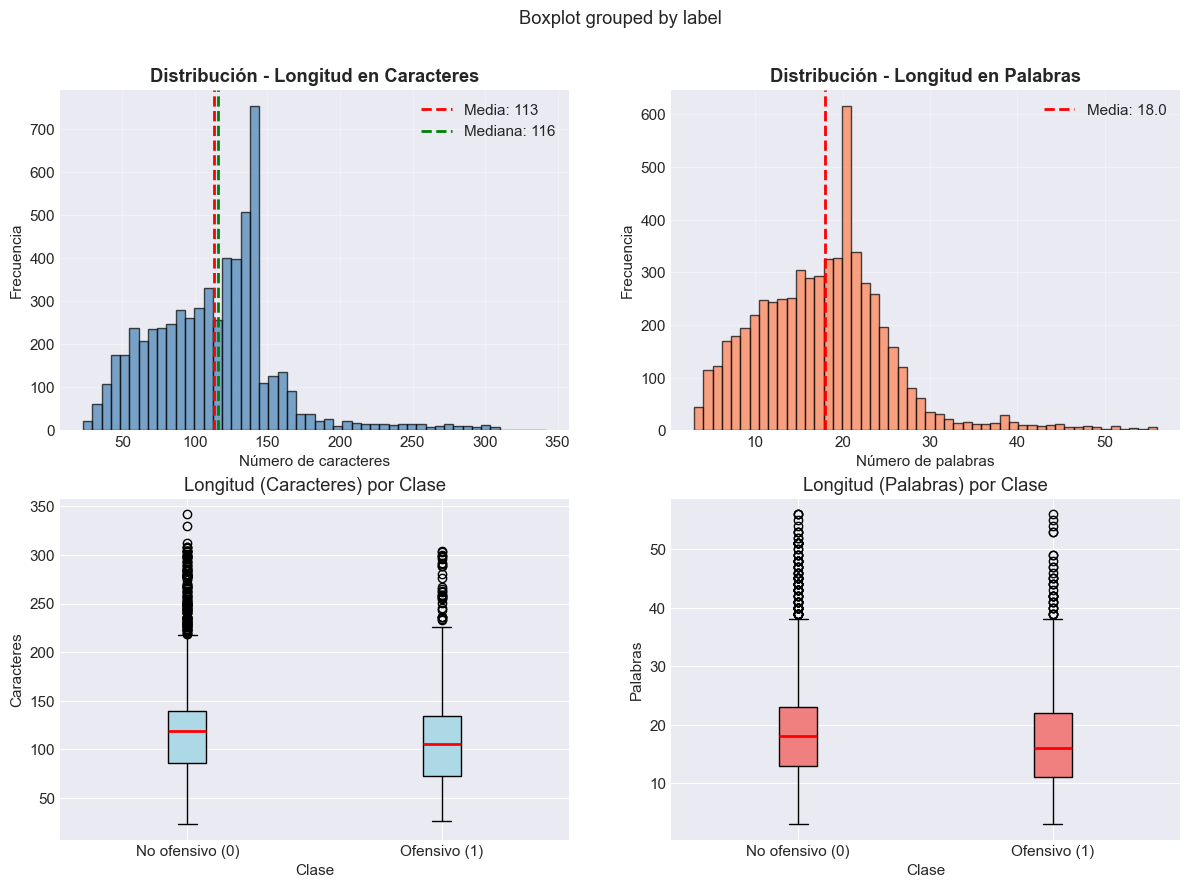

In [10]:

print(f"{'='*70}")
print(f"📏 ANÁLISIS DE LONGITUD DE TEXTOS")
print(f"{'='*70}")

# Calcular longitudes
df['longitud_chars'] = df['texto'].str.len()
df['longitud_palabras'] = df['texto'].str.split().str.len()

# Estadísticas generales
print(f"\n Estadísticas de longitud (caracteres):")
print(df['longitud_chars'].describe())

print(f"\n Estadísticas de longitud (palabras):")
print(df['longitud_palabras'].describe())

# Comparar por clase
print(f"\n Longitud promedio por clase:")
for label in sorted(df['label'].unique()):
    nombre = "No ofensivo" if label == 0 else "Ofensivo/Hate"
    avg_chars = df[df['label']==label]['longitud_chars'].mean()
    avg_words = df[df['label']==label]['longitud_palabras'].mean()
    median_chars = df[df['label']==label]['longitud_chars'].median()
    
    print(f"\n   Clase {label} ({nombre}):")
    print(f"      Media: {avg_chars:.1f} caracteres, {avg_words:.1f} palabras")
    print(f"      Mediana: {median_chars:.0f} caracteres")

# VISUALIZACIÓN
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histograma general - caracteres
axes[0, 0].hist(
    df['longitud_chars'], 
    bins=50, 
    color='steelblue', 
    edgecolor='black', 
    alpha=0.7
)
axes[0, 0].axvline(
    df['longitud_chars'].mean(), 
    color='red', 
    linestyle='--', 
    linewidth=2, 
    label=f'Media: {df["longitud_chars"].mean():.0f}'
)
axes[0, 0].axvline(
    df['longitud_chars'].median(), 
    color='green', 
    linestyle='--', 
    linewidth=2, 
    label=f'Mediana: {df["longitud_chars"].median():.0f}'
)
axes[0, 0].set_title('Distribución - Longitud en Caracteres', fontweight='bold')
axes[0, 0].set_xlabel('Número de caracteres')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Histograma general - palabras
axes[0, 1].hist(
    df['longitud_palabras'], 
    bins=50, 
    color='coral', 
    edgecolor='black', 
    alpha=0.7
)
axes[0, 1].axvline(
    df['longitud_palabras'].mean(), 
    color='red', 
    linestyle='--', 
    linewidth=2, 
    label=f'Media: {df["longitud_palabras"].mean():.1f}'
)
axes[0, 1].set_title('Distribución - Longitud en Palabras', fontweight='bold')
axes[0, 1].set_xlabel('Número de palabras')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Boxplot por clase - caracteres
df.boxplot(
    column='longitud_chars', 
    by='label', 
    ax=axes[1, 0],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue', edgecolor='black'),
    medianprops=dict(color='red', linewidth=2),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black')
)
axes[1, 0].set_title('Longitud (Caracteres) por Clase')
axes[1, 0].set_xlabel('Clase')
axes[1, 0].set_ylabel('Caracteres')
axes[1, 0].set_xticklabels(['No ofensivo (0)', 'Ofensivo (1)'])
plt.sca(axes[1, 0])
plt.xticks(rotation=0)

# Boxplot por clase - palabras
df.boxplot(
    column='longitud_palabras', 
    by='label', 
    ax=axes[1, 1],
    patch_artist=True,
    boxprops=dict(facecolor='lightcoral', edgecolor='black'),
    medianprops=dict(color='red', linewidth=2),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black')
)
axes[1, 1].set_title('Longitud (Palabras) por Clase')
axes[1, 1].set_xlabel('Clase')
axes[1, 1].set_ylabel('Palabras')
axes[1, 1].set_xticklabels(['No ofensivo (0)', 'Ofensivo (1)'])
plt.sca(axes[1, 1])
plt.xticks(rotation=0)


plt.show()


## 5. Ejemplos del Dataset

Ver ejemplos reales nos ayuda a entender:
- ¿Qué tipo de contenido tenemos?
- ¿Las etiquetas tienen sentido?
- ¿Hay patrones claros?

In [11]:

print(f"{'='*70}")
print(f"👀 EJEMPLOS ALEATORIOS DEL DATASET")
print(f"{'='*70}")

# Semilla aleatoria para reproducibilidad
np.random.seed(42)

# Clase 0 (No ofensivo)
print(f"\n▶ CLASE 0 (No ofensivo) - 15 ejemplos aleatorios:")
print(f"{'-'*70}")

ejemplos_0 = df[df['label']==0]['texto'].sample(15, random_state=42).values

for i, texto in enumerate(ejemplos_0, 1):
    # Limitar a 120 caracteres para no saturar
    texto_mostrar = texto if len(texto) <= 120 else texto[:117] + '...'
    print(f"{i:2d}. {texto_mostrar}")

# Clase 1 (Ofensivo)
print(f"\n▶ CLASE 1 (Ofensivo/Hate speech) - 15 ejemplos aleatorios:")
print(f"{'-'*70}")

ejemplos_1 = df[df['label']==1]['texto'].sample(15, random_state=42).values

for i, texto in enumerate(ejemplos_1, 1):
    texto_mostrar = texto if len(texto) <= 120 else texto[:117] + '...'
    print(f"{i:2d}. {texto_mostrar}")

# Encontrar los más cortos y más largos
print(f"\n{'='*70}")
print(f" EJEMPLOS EXTREMOS (MÁS CORTOS Y MÁS LARGOS)")
print(f"{'='*70}")

# Más corto
idx_corto = df['longitud_chars'].idxmin()
print(f"\n Texto MÁS CORTO ({df.loc[idx_corto, 'longitud_chars']} caracteres):")
print(f"   Clase: {df.loc[idx_corto, 'label']}")
print(f"   Texto: '{df.loc[idx_corto, 'texto']}'")

# Más largo
idx_largo = df['longitud_chars'].idxmax()
print(f"\n Texto MÁS LARGO ({df.loc[idx_largo, 'longitud_chars']} caracteres):")
print(f"   Clase: {df.loc[idx_largo, 'label']}")
print(f"   Texto: '{df.loc[idx_largo, 'texto'][:200]}...'")

👀 EJEMPLOS ALEATORIOS DEL DATASET

▶ CLASE 0 (No ofensivo) - 15 ejemplos aleatorios:
----------------------------------------------------------------------
 1. @Jorgekoine La bibliografía, sobre los nazis y la "ciencia judía", los comunistas y la "ciencia burguesa", las fem. d...
 2. Qué pasaría si gobernara Unidos Podemos? Una dictadura fascista donde el estado de derecho brillaría por su ausencia ...
 3. #ElCascabel26J Y ahora, por si la abuela no se había puesto interesante aparece el Rojo pájaro charrán en "vuelo rasa...
 4. @Cosmopaletista Facha tomandose en serio un tuit humorístico de @pedroveraOyP .
 5. Independentista Rajoy https://t.co/M9YKXCZJYE via @ARAopinio
 6. Lo que sintieron los indios en sendas finales no debe ser muy distinto a esta mierda.
 7. Parezco monguer @ Jadraque, Spain https://t.co/d8uqS7sJvZ
 8. @Moncholab Mira, un facha! https://t.co/rEy0dm0hav
 9. @MarinaCL32 @rubia50tdq @DeellSur cuánto mongolo hay suelto jajjajaja
10. Comienza la temporada de la grosell

## 6. Palabras Más Frecuentes por Clase

Analizar las palabras más comunes nos ayuda a:
- Entender el vocabulario de cada clase
- Detectar patrones lingüísticos
- Identificar posibles problemas de etiquetado

 PALABRAS MÁS FRECUENTES POR CLASE

 Top 20 palabras - Clase 0 (No ofensivo):
    1. independentista (  526 veces)
    2. subnormal       (  332 veces)
    3. eres            (  312 veces)
    4. fascista        (  226 veces)
    5. facha           (  225 veces)
    6. soy             (  224 veces)
    7. fascistas       (  176 veces)
    8. negro           (  157 veces)
    9. fachas          (  144 veces)
   10. mayoría         (  141 veces)
   11. género          (  128 veces)
   12. está            (  126 veces)
   13. será            (  125 veces)
   14. gente           (  124 veces)
   15. muerte          (  122 veces)
   16. tiene           (  120 veces)
   17. dictador        (  119 veces)
   18. catalán         (  117 veces)
   19. gay             (  113 veces)
   20. socialista      (  109 veces)

 Top 20 palabras - Clase 1 (Ofensivo/Hate):
    1. subnormal       (  384 veces)
    2. eres            (  171 veces)
    3. mierda          (  156 veces)
    4. puto            (  

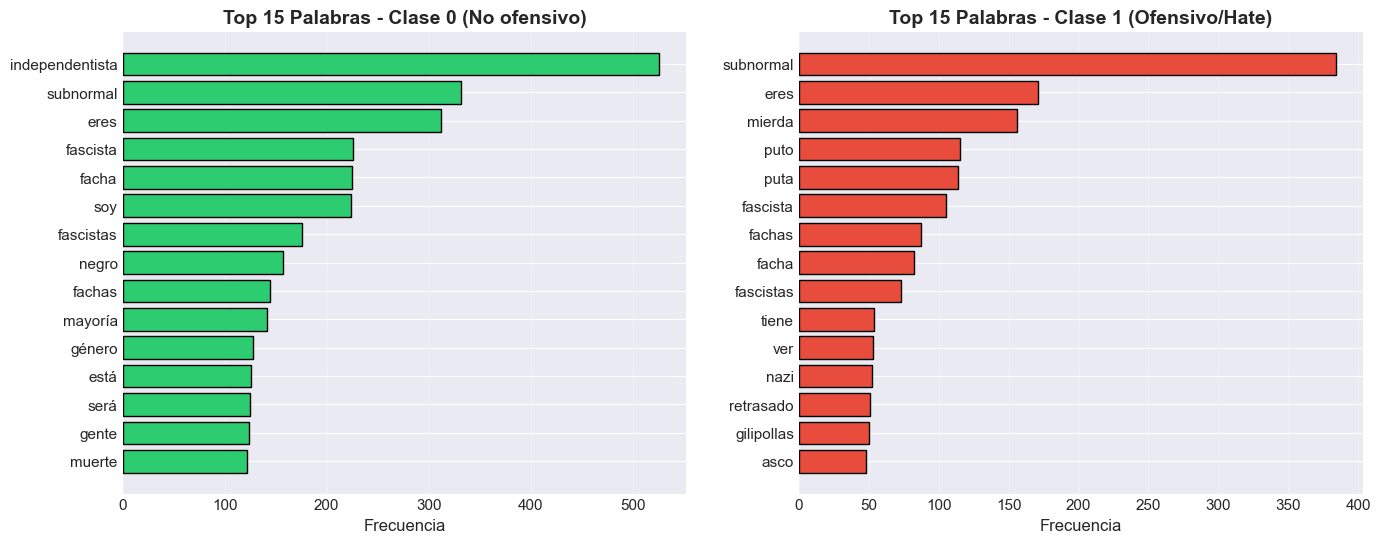

In [12]:

from collections import Counter
import re

print(f"{'='*70}")
print(f" PALABRAS MÁS FRECUENTES POR CLASE")
print(f"{'='*70}")

def limpiar_texto(texto):
    """Limpia y normaliza el texto"""
    # Convertir a minúsculas
    texto = texto.lower()
    # Quitar URLs
    texto = re.sub(r'http\S+|www\S+', '', texto)
    # Quitar menciones y hashtags
    texto = re.sub(r'@\w+|#\w+', '', texto)
    # Quitar puntuación
    texto = re.sub(r'[^\w\s]', ' ', texto)
    # Quitar números
    texto = re.sub(r'\d+', '', texto)
    # Quitar espacios múltiples
    texto = re.sub(r'\s+', ' ', texto)
    return texto.strip()

# Palabras comunes a eliminar (stopwords básicas en español)
stopwords_es = {
    'de', 'la', 'que', 'el', 'en', 'y', 'a', 'los', 'del', 'se', 'las',
    'por', 'un', 'para', 'con', 'no', 'una', 'su', 'al', 'lo', 'como',
    'más', 'pero', 'sus', 'le', 'ya', 'o', 'este', 'sí', 'porque', 'esta',
    'entre', 'cuando', 'muy', 'sin', 'sobre', 'también', 'me', 'hasta',
    'hay', 'donde', 'quien', 'desde', 'todo', 'nos', 'durante', 'todos',
    'uno', 'les', 'ni', 'contra', 'otros', 'ese', 'eso', 'ante', 'ellos',
    'e', 'esto', 'mí', 'antes', 'algunos', 'qué', 'unos', 'yo', 'otro',
    'otras', 'otra', 'él', 'tanto', 'esa', 'estos', 'mucho', 'quienes',
    'nada', 'muchos', 'cual', 'poco', 'ella', 'estar', 'estas', 'algunas',
    'algo', 'nosotros', 'mi', 'mis', 'tú', 'te', 'ti', 'tu', 'tus', 'ellas',
    'nosotras', 'vosotros', 'vosotras', 'os', 'mío', 'mía', 'míos', 'mías',
    'rt', 'q', 'si', 'ser', 'ha', 'he', 'es', 'son', 'así', 'fue', 'están'
}

# Analizar clase 0
textos_0 = ' '.join(df[df['label']==0]['texto'].apply(limpiar_texto))
palabras_0 = [p for p in textos_0.split() if len(p) > 2 and p not in stopwords_es]
freq_0 = Counter(palabras_0).most_common(20)

# Analizar clase 1
textos_1 = ' '.join(df[df['label']==1]['texto'].apply(limpiar_texto))
palabras_1 = [p for p in textos_1.split() if len(p) > 2 and p not in stopwords_es]
freq_1 = Counter(palabras_1).most_common(20)

# Mostrar resultados
print(f"\n Top 20 palabras - Clase 0 (No ofensivo):")
for i, (palabra, freq) in enumerate(freq_0, 1):
    print(f"   {i:2d}. {palabra:15s} ({freq:5,} veces)")

print(f"\n Top 20 palabras - Clase 1 (Ofensivo/Hate):")
for i, (palabra, freq) in enumerate(freq_1, 1):
    print(f"   {i:2d}. {palabra:15s} ({freq:5,} veces)")

# VISUALIZACIÓN
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Clase 0
palabras_0_top, freq_0_top = zip(*freq_0[:15])
axes[0].barh(range(15), freq_0_top, color='#2ecc71', edgecolor='black')
axes[0].set_yticks(range(15))
axes[0].set_yticklabels(palabras_0_top)
axes[0].invert_yaxis()
axes[0].set_xlabel('Frecuencia', fontsize=12)
axes[0].set_title('Top 15 Palabras - Clase 0 (No ofensivo)', fontweight='bold', fontsize=14)
axes[0].grid(axis='x', alpha=0.3)

# Clase 1
palabras_1_top, freq_1_top = zip(*freq_1[:15])
axes[1].barh(range(15), freq_1_top, color='#e74c3c', edgecolor='black')
axes[1].set_yticks(range(15))
axes[1].set_yticklabels(palabras_1_top)
axes[1].invert_yaxis()
axes[1].set_xlabel('Frecuencia', fontsize=12)
axes[1].set_title('Top 15 Palabras - Clase 1 (Ofensivo/Hate)', fontweight='bold', fontsize=14)
axes[1].grid(axis='x', alpha=0.3)

plt.show()

